In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

snapshot = joblib.load("ipl_auction_master_snapshot.joblib")

for name, value in snapshot.items():
    globals()[name] = value

print("✅ IPL Auction ML project loaded")
print("Final model features:", len(final_feature_columns))

✅ IPL Auction ML project loaded
Final model features: 41


In [2]:
# ============================================================
# MODEL INTERPRETATION — FEATURE IMPORTANCE
# ============================================================

importance_df = feature_importance.copy()

print("Feature importance shape:", importance_df.shape)
print("\nColumns:")
print(importance_df.columns.tolist())

print("\nTop 15 features:")
display(
    importance_df
    .sort_values("importance", ascending=False)
    .head(15)
)

Feature importance shape: (46, 3)

Columns:
['feature', 'importance', 'importance_pct']

Top 15 features:


,feature,importance,importance_pct
0,recent3_runs,0.201463,20.146325
1,last_season_wickets,0.092553,9.255345
2,career_batting_sr_before,0.059891,5.989092
3,last_season_runs,0.057670,5.767016
4,previous_auction_price,0.052053,5.205253
5,last_season_balls_bowled,0.040029,4.002946
6,last_season_balls,0.039780,3.978024
7,last_season_sr,0.037343,3.734284
8,experience_years,0.031975,3.197473
9,career_sixes_before,0.028633,2.863287


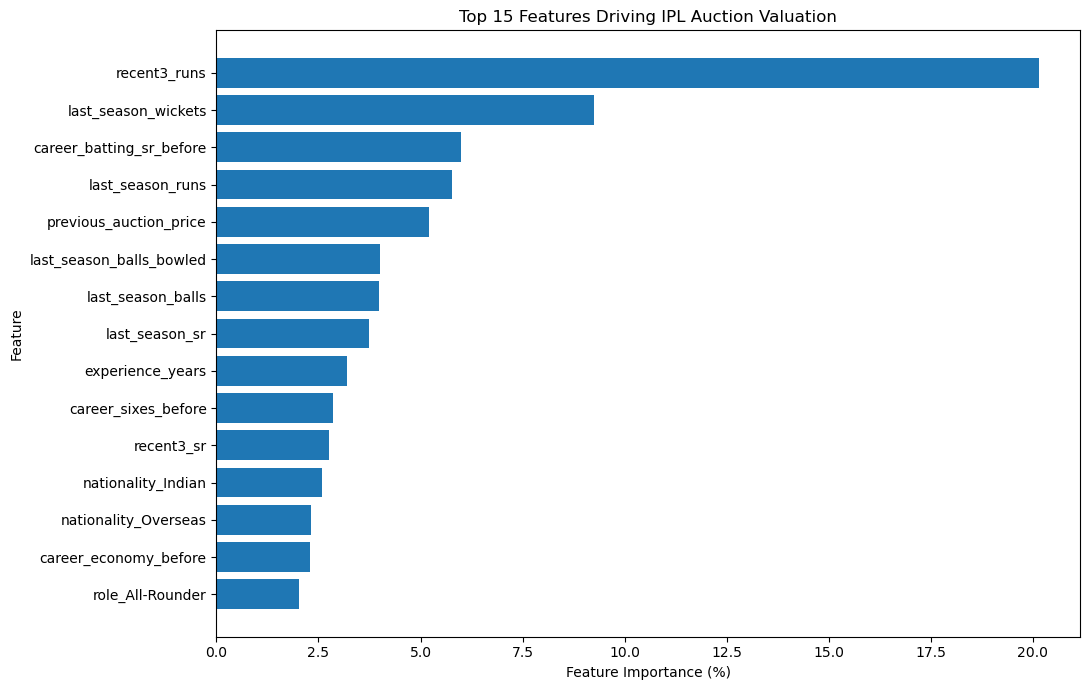

In [3]:
# ============================================================
# TOP 15 FEATURES — IPL AUCTION VALUATION MODEL
# ============================================================

import matplotlib.pyplot as plt

top15 = (
    importance_df
    .sort_values("importance_pct", ascending=False)
    .head(15)
    .sort_values("importance_pct")
)

plt.figure(figsize=(11, 7))

plt.barh(
    top15["feature"],
    top15["importance_pct"]
)

plt.xlabel("Feature Importance (%)")
plt.ylabel("Feature")
plt.title("Top 15 Features Driving IPL Auction Valuation")

plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# STEP 3 — FEATURE GROUP IMPORTANCE
# ============================================================

importance_grouped = importance_df.copy()


def classify_feature(feature):

    # -------------------------
    # Performance
    # -------------------------
    if (
        feature.startswith("recent3_")
        or feature.startswith("last_season_")
        or feature.startswith("career_runs")
        or feature.startswith("career_balls")
        or feature.startswith("career_innings")
        or feature.startswith("career_hundreds")
        or feature.startswith("career_fifties")
        or feature.startswith("career_fours")
        or feature.startswith("career_sixes")
        or feature.startswith("career_batting_sr")
        or feature.startswith("career_wickets")
        or feature.startswith("career_balls_bowled")
        or feature.startswith("career_runs_conceded")
        or feature.startswith("career_3w")
        or feature.startswith("career_4w")
        or feature.startswith("career_5w")
        or feature.startswith("career_economy")
    ):
        return "Performance"

    # -------------------------
    # Auction History
    # -------------------------
    elif (
        feature.startswith("previous_auction")
    ):
        return "Auction History"

    # -------------------------
    # Experience
    # -------------------------
    elif (
        feature.startswith("experience_")
        or feature.startswith("career_seasons_")
    ):
        return "Experience"

    # -------------------------
    # Player Context
    # -------------------------
    elif (
        feature.startswith("role_")
        or feature.startswith("nationality_")
    ):
        return "Player Context"

    # -------------------------
    # Other
    # -------------------------
    else:
        return "Other"


importance_grouped["group"] = (
    importance_grouped["feature"]
    .apply(classify_feature)
)


group_summary = (
    importance_grouped
    .groupby("group", as_index=False)["importance_pct"]
    .sum()
    .sort_values(
        "importance_pct",
        ascending=False
    )
)


print("Feature importance by group:")
display(group_summary)

Feature importance by group:


,group,importance_pct
3,Performance,77.768454
4,Player Context,10.311360
0,Auction History,6.264613
1,Experience,4.767800
2,Other,0.887773


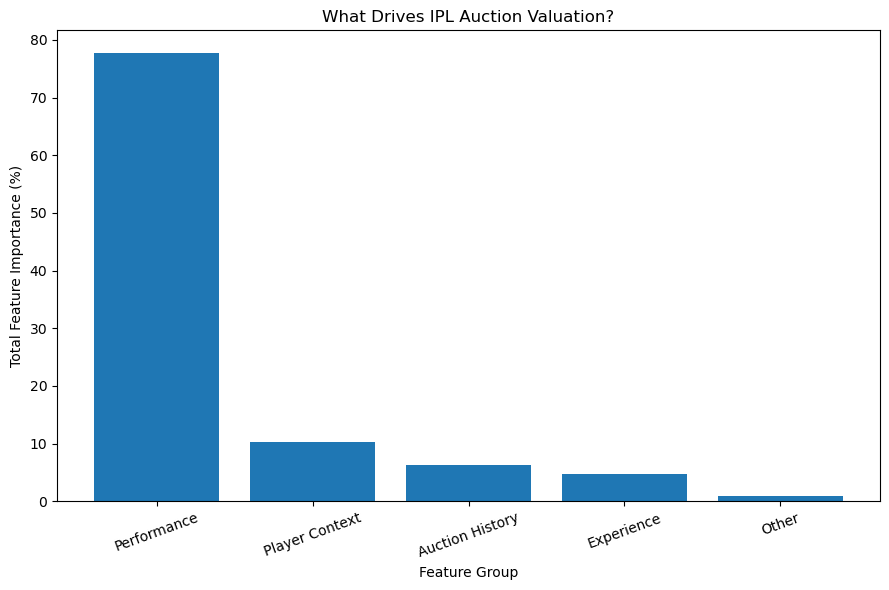

In [5]:
# ============================================================
# FEATURE GROUP IMPORTANCE CHART
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    group_summary["group"],
    group_summary["importance_pct"]
)

plt.ylabel("Total Feature Importance (%)")
plt.xlabel("Feature Group")
plt.title("What Drives IPL Auction Valuation?")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# STEP 4 — BATTING VS BOWLING IMPORTANCE
# ============================================================

performance_df = importance_df.copy()


def classify_performance(feature):

    # Batting features
    if (
        "runs" in feature
        or "balls" in feature
        or "batting" in feature
        or "strike" in feature
        or "fifties" in feature
        or "hundreds" in feature
        or "fours" in feature
        or "sixes" in feature
    ):
        return "Batting"

    # Bowling features
    elif (
        "wickets" in feature
        or "bowling" in feature
        or "economy" in feature
        or "conceded" in feature
        or "3w" in feature
        or "4w" in feature
        or "5w" in feature
    ):
        return "Bowling"

    else:
        return "Other"


performance_df["performance_type"] = (
    performance_df["feature"]
    .apply(classify_performance)
)


performance_summary = (
    performance_df
    .groupby("performance_type", as_index=False)["importance_pct"]
    .sum()
    .sort_values(
        "importance_pct",
        ascending=False
    )
)


print("Performance importance breakdown:")
display(performance_summary)

Performance importance breakdown:


,performance_type,importance_pct
0,Batting,51.682229
2,Other,29.426990
1,Bowling,18.890781


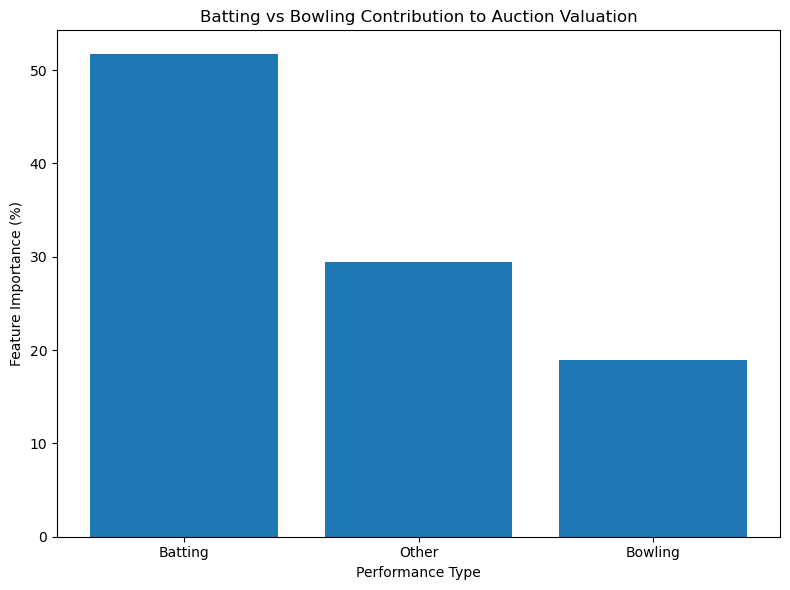

In [7]:
# ============================================================
# BATTING VS BOWLING IMPORTANCE
# ============================================================

plt.figure(figsize=(8, 6))

plt.bar(
    performance_summary["performance_type"],
    performance_summary["importance_pct"]
)

plt.xlabel("Performance Type")
plt.ylabel("Feature Importance (%)")
plt.title("Batting vs Bowling Contribution to Auction Valuation")

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# CORRECT PERFORMANCE GROUPING
# ============================================================

def classify_performance(feature):

    # -------------------------
    # Bowling features
    # -------------------------
    bowling_keywords = [
        "wickets",
        "bowling",
        "economy",
        "conceded",
        "3w",
        "4w",
        "5w"
    ]

    if any(keyword in feature for keyword in bowling_keywords):
        return "Bowling"


    # -------------------------
    # Batting features
    # -------------------------
    batting_keywords = [
        "runs",
        "balls",
        "batting",
        "strike",
        "fifties",
        "hundreds",
        "fours",
        "sixes"
    ]

    if any(keyword in feature for keyword in batting_keywords):
        return "Batting"


    return "Other"


performance_df = importance_df.copy()

performance_df["performance_type"] = (
    performance_df["feature"]
    .apply(classify_performance)
)


performance_summary = (
    performance_df
    .groupby(
        "performance_type",
        as_index=False
    )["importance_pct"]
    .sum()
    .sort_values(
        "importance_pct",
        ascending=False
    )
)


print("Corrected performance importance:")
display(performance_summary)

Corrected performance importance:


,performance_type,importance_pct
0,Batting,51.079826
2,Other,29.426990
1,Bowling,19.493184


In [9]:
# ============================================================
# STEP 5 — ACTUAL VS PREDICTED AUCTION PRICE
# ============================================================

evaluation_df = pd.DataFrame({
    "actual_price": y_test_exp.values,
    "predicted_price": experience_predictions
})

print("Evaluation dataset:")
print(evaluation_df.shape)

display(evaluation_df.head())

Evaluation dataset:
(150, 2)


,actual_price,predicted_price
0,50.0,115.474776
1,240.0,283.047073
2,100.0,303.750865
3,200.0,387.800583
4,825.0,465.069856


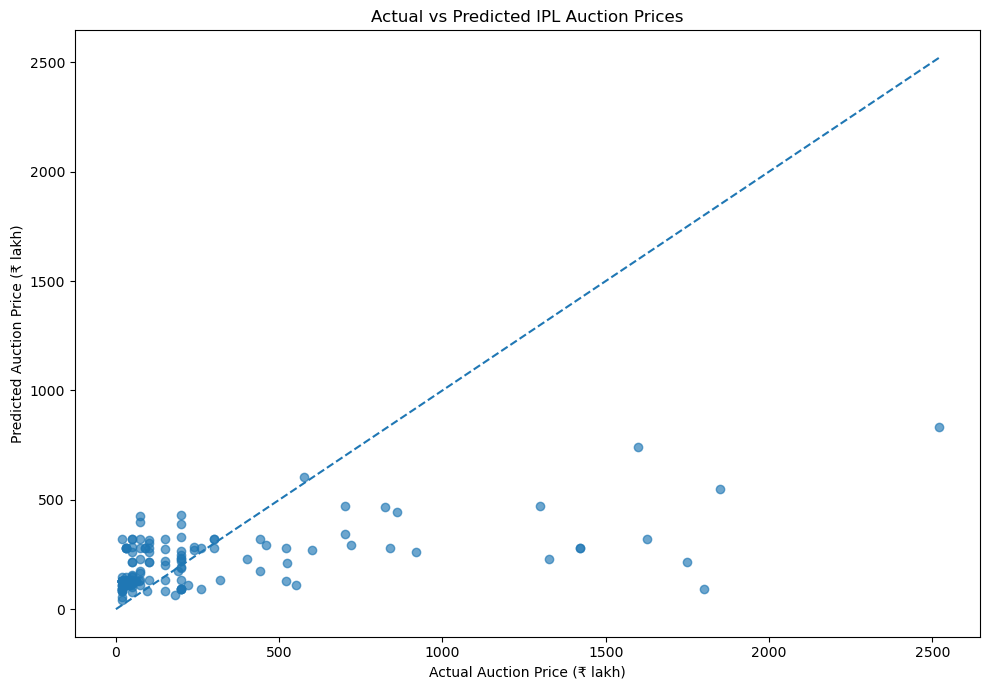

In [10]:
# ============================================================
# ACTUAL VS PREDICTED PRICE
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    evaluation_df["actual_price"],
    evaluation_df["predicted_price"],
    alpha=0.65
)

# Perfect prediction line
max_value = max(
    evaluation_df["actual_price"].max(),
    evaluation_df["predicted_price"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Auction Price (₹ lakh)")
plt.ylabel("Predicted Auction Price (₹ lakh)")
plt.title("Actual vs Predicted IPL Auction Prices")

plt.tight_layout()
plt.show()

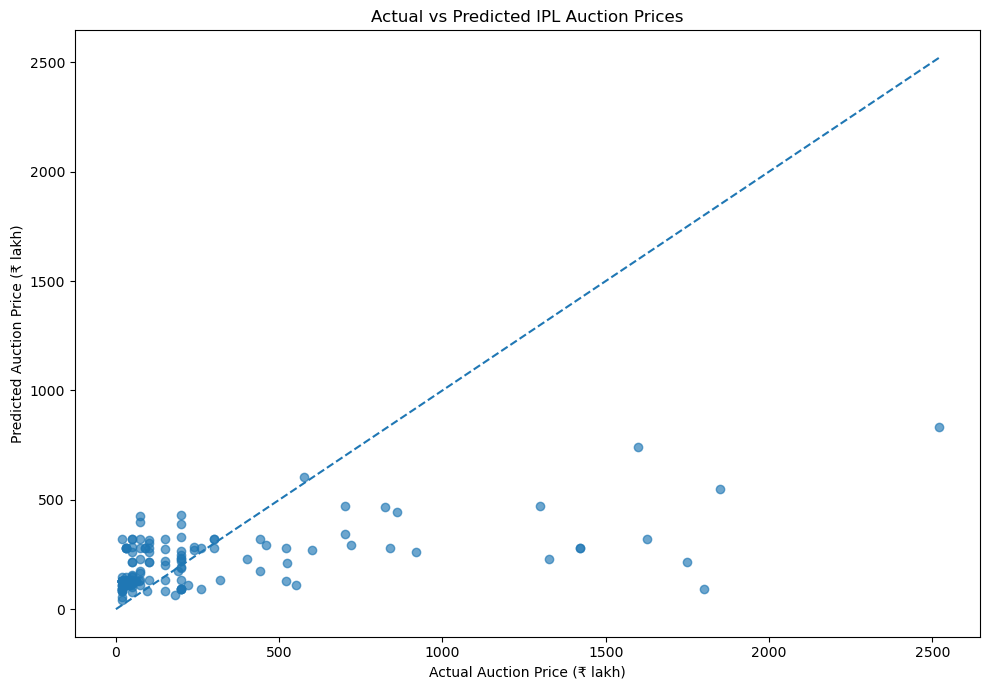

In [11]:
# ============================================================
# ACTUAL VS PREDICTED AUCTION PRICE
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    evaluation_df["actual_price"],
    evaluation_df["predicted_price"],
    alpha=0.65
)

max_value = max(
    evaluation_df["actual_price"].max(),
    evaluation_df["predicted_price"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Auction Price (₹ lakh)")
plt.ylabel("Predicted Auction Price (₹ lakh)")
plt.title("Actual vs Predicted IPL Auction Prices")

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# STEP 6 — ERROR ANALYSIS BY AUCTION PRICE
# ============================================================

evaluation_df["error"] = (
    evaluation_df["predicted_price"]
    - evaluation_df["actual_price"]
)

evaluation_df["absolute_error"] = (
    evaluation_df["error"].abs()
)


# ------------------------------------------------------------
# Create price bands
# ------------------------------------------------------------

def price_band(price):

    if price < 50:
        return "₹0–50L"

    elif price < 100:
        return "₹50–100L"

    elif price < 250:
        return "₹100–250L"

    elif price < 500:
        return "₹250–500L"

    elif price < 1000:
        return "₹500–1000L"

    else:
        return "₹1000L+"


evaluation_df["price_band"] = (
    evaluation_df["actual_price"]
    .apply(price_band)
)


# ------------------------------------------------------------
# Calculate band-level performance
# ------------------------------------------------------------

error_by_band = (
    evaluation_df
    .groupby("price_band", sort=False)
    .agg(
        players=("actual_price", "count"),
        MAE=("absolute_error", "mean"),
        average_actual=("actual_price", "mean"),
        average_predicted=("predicted_price", "mean")
    )
    .reset_index()
)


print("ERROR BY AUCTION PRICE BAND")
print("=" * 70)

display(error_by_band)

ERROR BY AUCTION PRICE BAND


,price_band,players,MAE,average_actual,average_predicted
0,₹50–100L,30,138.118177,63.333333,200.518051
1,₹100–250L,33,93.882873,171.818182,214.805275
2,₹500–1000L,13,365.056552,681.153846,320.262913
3,₹1000L+,10,1259.157274,1661.000000,401.842726
4,₹250–500L,10,116.175686,348.000000,244.678632
5,₹0–50L,54,107.367978,26.018519,133.386497


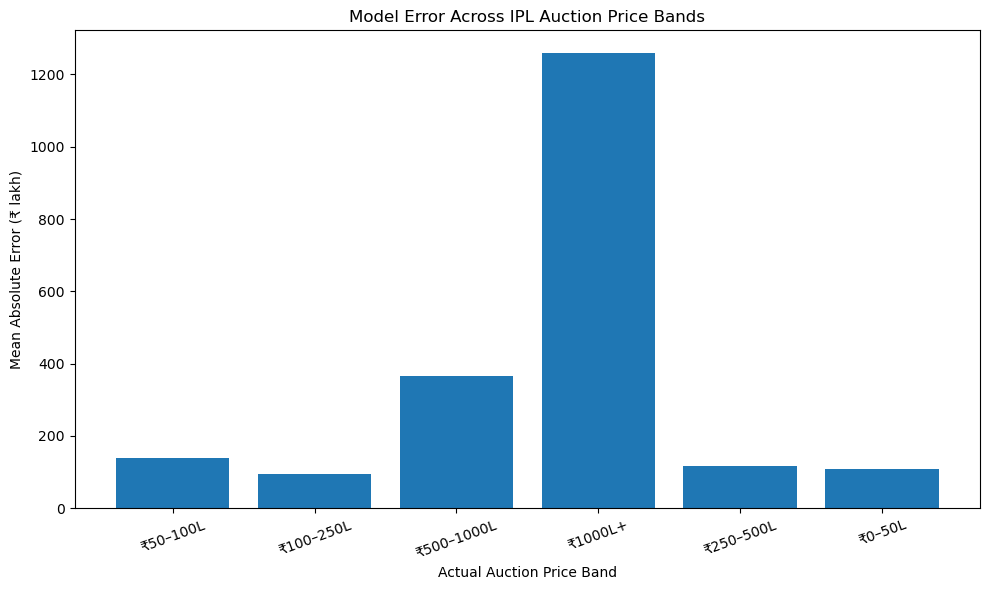

In [13]:
# ============================================================
# MAE BY AUCTION PRICE BAND
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    error_by_band["price_band"],
    error_by_band["MAE"]
)

plt.xlabel("Actual Auction Price Band")
plt.ylabel("Mean Absolute Error (₹ lakh)")
plt.title("Model Error Across IPL Auction Price Bands")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# STEP 7 — TOP 10 BIGGEST PREDICTION ERRORS
# ============================================================

# Add player information from the temporal test set
error_analysis = evaluation_df.copy()

error_analysis["player_name"] = auction_model.loc[
    y_test_exp.index, "player_name"
].values

error_analysis["auction_year"] = auction_model.loc[
    y_test_exp.index, "year"
].values

error_analysis["error_direction"] = np.where(
    error_analysis["error"] > 0,
    "Overpredicted",
    "Underpredicted"
)

# Sort by absolute error
top_10_errors = (
    error_analysis
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

# Select useful columns
top_10_errors = top_10_errors[
    [
        "player_name",
        "auction_year",
        "actual_price",
        "predicted_price",
        "error",
        "absolute_error",
        "error_direction"
    ]
].reset_index(drop=True)

print("TOP 10 BIGGEST PREDICTION ERRORS")
print("=" * 80)

display(top_10_errors)

TOP 10 BIGGEST PREDICTION ERRORS


,player_name,auction_year,actual_price,predicted_price,error,absolute_error,error_direction
0,Akeal Hosein,2026,1800.0,92.460841,-1707.539159,1707.539159,Underpredicted
1,James Faulkner,2012,2520.0,834.737993,-1685.262007,1685.262007,Underpredicted
2,Azhar Mahmood,2012,1750.0,216.681169,-1533.318831,1533.318831,Underpredicted
3,John Hastings,2011,1850.0,547.053703,-1302.946297,1302.946297,Underpredicted
4,Aiden Blizzard,2011,1625.0,322.188139,-1302.811861,1302.811861,Underpredicted
5,Ben Duckett,2026,1420.0,281.835186,-1138.164814,1138.164814,Underpredicted
6,Anrich Nortje,2026,1420.0,281.835186,-1138.164814,1138.164814,Underpredicted
7,Shams Mulani,2023,1325.0,230.406866,-1094.593134,1094.593134,Underpredicted
8,Doug Bollinger,2010,1600.0,740.914068,-859.085932,859.085932,Underpredicted
9,Mohammed Kaif,2011,1300.0,470.314111,-829.685889,829.685889,Underpredicted


In [15]:
# ============================================================
# STEP 8 — PROFILE THE BIGGEST MODEL FAILURES
# ============================================================

# Get the original test rows
failure_profile = auction_model.loc[
    y_test_exp.index
].copy()

# Add predictions and errors
failure_profile["predicted_price"] = experience_predictions

failure_profile["absolute_error"] = (
    failure_profile["final_price_lakh"]
    - failure_profile["predicted_price"]
).abs()

# Select the 10 largest errors
failure_profile = (
    failure_profile
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

# Display the most useful explanatory features
failure_columns = [
    "player_name",
    "year",
    "role",
    "nationality",
    "final_price_lakh",
    "predicted_price",
    "previous_auction_price",
    "previous_auction_count",
    "experience_years",
    "career_seasons_before",
    "recent3_runs",
    "recent3_sr",
    "last_season_runs",
    "last_season_sr",
    "recent3_wickets",
    "last_season_wickets",
    "last_season_economy",
    "career_wickets_before",
    "has_batting_history",
    "has_bowling_history"
]

failure_profile[
    [col for col in failure_columns if col in failure_profile.columns]
].reset_index(drop=True)

,player_name,year,role,nationality,final_price_lakh,predicted_price,previous_auction_price,previous_auction_count,recent3_runs,recent3_sr,last_season_runs,last_season_sr,recent3_wickets,last_season_wickets,last_season_economy,career_wickets_before,has_batting_history,has_bowling_history
0,Cameron Green,2026,Unknown,Overseas,2520.0,130.616883,1750.0,1.0,707,153.695652,255,143.258427,16,10,8.616114,16,1,1
1,Matheesha Pathirana,2026,Unknown,Overseas,1800.0,126.452216,0.0,NaN,0,0.000000,0,0.000000,0,0,0.000000,0,0,0
2,Kartik Sharma,2026,Unknown,Indian,1420.0,133.206247,0.0,NaN,0,0.000000,0,0.000000,0,0,0.000000,0,0,0
3,Prashant Veer,2026,Unknown,Indian,1420.0,321.218203,0.0,NaN,0,0.000000,0,0.000000,0,0,0.000000,0,0,0
4,Liam Livingstone,2026,Unknown,Overseas,1300.0,321.218203,1150.0,3.0,502,150.750751,112,133.333333,7,2,8.444444,13,1,1
5,Mustafizur Rahman,2026,Bowler,Overseas,920.0,110.835496,200.0,4.0,4,57.142857,0,0.000000,19,4,7.909091,65,1,1
6,James Faulkner,2012,None,Overseas,95.0,834.737993,0.0,0.0,0,0.000000,0,0.000000,1,1,4.500000,1,0,1
7,Josh Inglis,2026,Wicket-Keeper,Overseas,860.0,130.616883,0.0,0.0,278,162.573099,278,162.573099,0,0,0.000000,0,1,0
8,Auqib Nabi,2026,Unknown,Indian,840.0,130.616883,0.0,NaN,0,0.000000,0,0.000000,0,0,0.000000,0,0,0
9,Kevin Pietersen,2014,Batsman,Overseas,900.0,265.235380,247.5,2.0,634,141.202673,305,147.342995,7,0,8.833333,7,1,1


In [16]:
# ============================================================
# STEP 8A — VERIFY TEST DATA ALIGNMENT
# ============================================================

print("y_test_exp length:", len(y_test_exp))
print("Predictions length:", len(experience_predictions))
print("X_test_exp length:", len(X_test_exp))

print("\nFirst 10 y_test indices:")
print(y_test_exp.index[:10].tolist())

print("\nFirst 10 X_test indices:")
print(X_test_exp.index[:10].tolist())

print("\nIndex alignment:")
print("y_test == X_test:",
      y_test_exp.index.equals(X_test_exp.index))

print("\nPrediction length matches test set:",
      len(experience_predictions) == len(X_test_exp))

y_test_exp length: 150
Predictions length: 150
X_test_exp length: 150

First 10 y_test indices:
[18, 43, 55, 67, 98, 128, 133, 153, 168, 203]

First 10 X_test indices:
[18, 43, 55, 67, 98, 128, 133, 153, 168, 203]

Index alignment:
y_test == X_test: True

Prediction length matches test set: True


In [17]:
# ============================================================
# STEP 8B — REBUILD EVALUATION DATA SAFELY
# ============================================================

# Use the exact test-set indices
test_results = auction_model.loc[X_test_exp.index].copy()

# Store actual and predicted values in the same order
test_results["actual_price"] = y_test_exp.loc[X_test_exp.index].values
test_results["predicted_price"] = experience_predictions

# Calculate errors
test_results["error"] = (
    test_results["predicted_price"]
    - test_results["actual_price"]
)

test_results["absolute_error"] = (
    test_results["error"].abs()
)

# Biggest errors
correct_top_10 = (
    test_results
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

display(
    correct_top_10[
        [
            "player_name",
            "year",
            "actual_price",
            "predicted_price",
            "error",
            "absolute_error"
        ]
    ].reset_index(drop=True)
)

,player_name,year,actual_price,predicted_price,error,absolute_error
0,Akeal Hosein,2026,1800.0,92.460841,-1707.539159,1707.539159
1,James Faulkner,2012,2520.0,834.737993,-1685.262007,1685.262007
2,Azhar Mahmood,2012,1750.0,216.681169,-1533.318831,1533.318831
3,John Hastings,2011,1850.0,547.053703,-1302.946297,1302.946297
4,Aiden Blizzard,2011,1625.0,322.188139,-1302.811861,1302.811861
5,Ben Duckett,2026,1420.0,281.835186,-1138.164814,1138.164814
6,Anrich Nortje,2026,1420.0,281.835186,-1138.164814,1138.164814
7,Shams Mulani,2023,1325.0,230.406866,-1094.593134,1094.593134
8,Doug Bollinger,2010,1600.0,740.914068,-859.085932,859.085932
9,Mohammed Kaif,2011,1300.0,470.314111,-829.685889,829.685889


In [18]:
# ============================================================
# STEP 9 — PROFILE CORRECT TOP 10 FAILURES
# ============================================================

top_failure_indices = correct_top_10.index

failure_profile = test_results.loc[top_failure_indices].copy()

failure_columns = [
    "player_name",
    "year",
    "role",
    "nationality",
    "actual_price",
    "predicted_price",
    "previous_auction_price",
    "previous_auction_count",
    "experience_years",
    "career_seasons_before",
    "career_runs_before",
    "career_batting_sr_before",
    "recent3_runs",
    "recent3_sr",
    "last_season_runs",
    "last_season_sr",
    "career_wickets_before",
    "recent3_wickets",
    "last_season_wickets",
    "last_season_economy",
    "has_batting_history",
    "has_bowling_history"
]

failure_profile_view = (
    failure_profile[
        [col for col in failure_columns if col in failure_profile.columns]
    ]
    .reset_index(drop=True)
)

display(failure_profile_view)

,player_name,year,role,nationality,actual_price,predicted_price,previous_auction_price,previous_auction_count,career_runs_before,career_batting_sr_before,recent3_runs,recent3_sr,last_season_runs,last_season_sr,career_wickets_before,recent3_wickets,last_season_wickets,last_season_economy,has_batting_history,has_bowling_history
0,Akeal Hosein,2026,Unknown,Overseas,1800.0,92.460841,100.0,1.0,16,160.0,16,160.000000,16,160.0,1,1,1,10.000000,1,1
1,James Faulkner,2012,None,Overseas,2520.0,834.737993,0.0,0.0,0,0.0,0,0.000000,0,0.0,1,1,1,4.500000,0,1
2,Azhar Mahmood,2012,None,Overseas,1750.0,216.681169,0.0,0.0,0,0.0,0,0.000000,0,0.0,0,0,0,0.000000,0,0
3,John Hastings,2011,None,Overseas,1850.0,547.053703,0.0,0.0,0,0.0,0,0.000000,0,0.0,0,0,0,0.000000,0,0
4,Aiden Blizzard,2011,None,Overseas,1625.0,322.188139,0.0,NaN,0,0.0,0,0.000000,0,0.0,0,0,0,0.000000,0,0
5,Ben Duckett,2026,Unknown,Overseas,1420.0,281.835186,0.0,NaN,0,0.0,0,0.000000,0,0.0,0,0,0,0.000000,0,0
6,Anrich Nortje,2026,Unknown,Overseas,1420.0,281.835186,20.0,1.0,49,100.0,42,97.674419,4,50.0,61,18,1,11.857143,1,1
7,Shams Mulani,2023,All-Rounder,Indian,1325.0,230.406866,0.0,0.0,0,0.0,0,0.000000,0,0.0,0,0,0,0.000000,0,0
8,Doug Bollinger,2010,Bowler,Overseas,1600.0,740.914068,0.0,0.0,0,0.0,0,0.000000,0,0.0,0,0,0,0.000000,0,0
9,Mohammed Kaif,2011,None,Indian,1300.0,470.314111,0.0,NaN,0,0.0,0,0.000000,0,0.0,0,0,0,0.000000,0,0


In [19]:
# ============================================================
# STEP 10 — ERROR BY PERFORMANCE HISTORY AVAILABILITY
# ============================================================

history_analysis = test_results.copy()

history_analysis["performance_history"] = np.where(
    (history_analysis["has_batting_history"] == 1) |
    (history_analysis["has_bowling_history"] == 1),
    "Has Performance History",
    "No Performance History"
)

history_summary = (
    history_analysis
    .groupby("performance_history")
    .agg(
        players=("actual_price", "count"),
        MAE=("absolute_error", "mean"),
        average_actual_price=("actual_price", "mean"),
        average_predicted_price=("predicted_price", "mean")
    )
    .reset_index()
)

display(history_summary)

,performance_history,players,MAE,average_actual_price,average_predicted_price
0,Has Performance History,60,225.431095,308.166667,232.191227
1,No Performance History,90,200.141667,215.888889,188.934936


In [20]:
# ============================================================
# STEP 10B — ERROR FOR EXTREME AUCTION PRICES
# ============================================================

history_analysis["price_category"] = np.where(
    history_analysis["actual_price"] >= 1000,
    "Extreme Price (₹10Cr+)",
    "Below ₹10Cr"
)

extreme_summary = (
    history_analysis
    .groupby("price_category")
    .agg(
        players=("actual_price", "count"),
        MAE=("absolute_error", "mean"),
        average_actual_price=("actual_price", "mean"),
        average_predicted_price=("predicted_price", "mean")
    )
    .reset_index()
)

display(extreme_summary)

,price_category,players,MAE,average_actual_price,average_predicted_price
0,Below ₹10Cr,140,135.336021,152.214286,192.265647
1,Extreme Price (₹10Cr+),10,1259.157274,1661.000000,401.842726


In [21]:
# ============================================================
# STEP 10A — ERROR BY PERFORMANCE HISTORY
# ============================================================

history_analysis = test_results.copy()

history_analysis["performance_history"] = np.where(
    (history_analysis["has_batting_history"] == 1) |
    (history_analysis["has_bowling_history"] == 1),
    "Has Performance History",
    "No Performance History"
)

history_summary = (
    history_analysis
    .groupby("performance_history")
    .agg(
        players=("actual_price", "count"),
        MAE=("absolute_error", "mean"),
        average_actual_price=("actual_price", "mean"),
        average_predicted_price=("predicted_price", "mean")
    )
    .reset_index()
)

display(history_summary)

,performance_history,players,MAE,average_actual_price,average_predicted_price
0,Has Performance History,60,225.431095,308.166667,232.191227
1,No Performance History,90,200.141667,215.888889,188.934936


In [22]:
# ============================================================
# STEP 10B — ERROR FOR EXTREME AUCTION PRICES
# ============================================================

history_analysis["price_category"] = np.where(
    history_analysis["actual_price"] >= 1000,
    "Extreme Price (₹10Cr+)",
    "Below ₹10Cr"
)

extreme_summary = (
    history_analysis
    .groupby("price_category")
    .agg(
        players=("actual_price", "count"),
        MAE=("absolute_error", "mean"),
        average_actual_price=("actual_price", "mean"),
        average_predicted_price=("predicted_price", "mean")
    )
    .reset_index()
)

display(extreme_summary)

,price_category,players,MAE,average_actual_price,average_predicted_price
0,Below ₹10Cr,140,135.336021,152.214286,192.265647
1,Extreme Price (₹10Cr+),10,1259.157274,1661.000000,401.842726


In [23]:
# ============================================================
# STEP 11 — FINAL MODEL PERFORMANCE SUMMARY
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

actual = test_results["actual_price"]
predicted = test_results["predicted_price"]

final_mae = mean_absolute_error(actual, predicted)

final_rmse = np.sqrt(
    mean_squared_error(actual, predicted)
)

final_r2 = r2_score(actual, predicted)

median_absolute_error = (
    test_results["absolute_error"].median()
)

p75_absolute_error = (
    test_results["absolute_error"].quantile(0.75)
)

p90_absolute_error = (
    test_results["absolute_error"].quantile(0.90)
)

overprediction_pct = (
    (test_results["error"] > 0).mean() * 100
)

underprediction_pct = (
    (test_results["error"] < 0).mean() * 100
)

summary = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²",
        "Median Absolute Error",
        "75th Percentile Absolute Error",
        "90th Percentile Absolute Error",
        "Overprediction Rate",
        "Underprediction Rate"
    ],
    "Value": [
        f"₹{final_mae:.2f} lakh",
        f"₹{final_rmse:.2f} lakh",
        f"{final_r2:.4f}",
        f"₹{median_absolute_error:.2f} lakh",
        f"₹{p75_absolute_error:.2f} lakh",
        f"₹{p90_absolute_error:.2f} lakh",
        f"{overprediction_pct:.1f}%",
        f"{underprediction_pct:.1f}%"
    ]
})

display(summary)

,Metric,Value
0,MAE,₹210.26 lakh
1,RMSE,₹373.87 lakh
2,R²,0.2490
3,Median Absolute Error,₹106.45 lakh
4,75th Percentile Absolute Error,₹206.06 lakh
5,90th Percentile Absolute Error,₹392.25 lakh
6,Overprediction Rate,72.0%
7,Underprediction Rate,28.0%


# Final Model Interpretation

## 1. Model Performance

The champion model is an Experience-Enhanced Random Forest Regressor evaluated using a temporal holdout strategy.

Training data consists of auction years up to 2022, while the model is evaluated on future auction years from 2023 onward.

### Held-Out Test Performance

| Metric | Result |
|---|---:|
| MAE | ₹210.26 lakh |
| RMSE | ₹373.87 lakh |
| R² | 0.2490 |
| Median Absolute Error | ₹106.45 lakh |
| 75th Percentile Absolute Error | ₹206.06 lakh |
| 90th Percentile Absolute Error | ₹392.25 lakh |

The model explains approximately 24.9% of the variation in future auction prices.

The median absolute error is approximately ₹1.06 crore, while 90% of predictions have an absolute error below approximately ₹3.92 crore.

---

## 2. Most Important Features

The model's most influential features include:

1. Recent 3-season runs
2. Last-season wickets
3. Career batting strike rate
4. Last-season runs
5. Previous auction price
6. Last-season balls bowled
7. Last-season balls faced
8. Last-season strike rate
9. Experience years
10. Career sixes

This indicates that recent player performance and historical auction information are important signals for estimating auction value.

Feature importance represents the model's predictive usage of these variables and should not be interpreted as causal relationships.

---

## 3. Feature Group Importance

The model's feature importance can be grouped into:

| Feature Group | Importance |
|---|---:|
| Performance | 77.77% |
| Player Context | 10.31% |
| Auction History | 6.26% |
| Experience | 4.77% |
| Other | 0.89% |

Performance-related features dominate the model, accounting for approximately 77.77% of the aggregated feature importance.

Among directly identifiable performance statistics, batting-related features contribute more importance than bowling-related features.

---

## 4. Error Analysis

The model performs substantially better for normal auction prices than for extreme auction outcomes.

| Auction Price | Players | MAE |
|---|---:|---:|
| Below ₹10 Cr | 140 | ₹135.34 lakh |
| ₹10 Cr+ | 10 | ₹1,259.16 lakh |

For players sold below ₹10 crore, the average absolute error is approximately ₹1.35 crore.

For players sold for ₹10 crore or more, the average absolute error increases to approximately ₹12.59 crore.

The average actual price of these extreme-price players was ₹16.61 crore, while the model predicted an average of only ₹4.02 crore.

This demonstrates a strong regression-toward-the-mean effect for exceptional auction outcomes.

---

## 5. Key Model Limitation

The model is designed primarily around historical player performance, experience, and previous auction information.

However, auction prices can also be influenced by factors that are not fully represented in the dataset, such as:

- bidding competition
- franchise-specific requirements
- player scarcity
- team strategy
- reputation and market demand
- current form not captured by historical IPL statistics
- availability of alternative players
- role scarcity within a particular auction

These factors may cause actual auction prices to deviate substantially from performance-based valuation.

Therefore, the model should be interpreted as a **data-driven valuation benchmark rather than an exact prediction of the final auction price**.

---

## 6. Business Interpretation

The model is most useful for identifying a player's approximate historical-performance-based market value.

Potential applications include:

- Pre-auction player valuation
- Shortlisting players within a budget
- Comparing players objectively
- Identifying potentially undervalued players
- Supporting auction strategy
- Creating player valuation dashboards

The model should be combined with qualitative scouting and current auction-market information when making actual purchasing decisions.

---

## 7. Final Conclusion

The analysis demonstrates that historical performance, recent form, experience, and auction history contain useful information for estimating IPL player auction value.

The model performs reasonably better on normal-priced players but struggles with exceptional ₹10 crore+ auction outcomes.

The main insight is that IPL auction prices are influenced by both measurable player performance and market-driven factors that are difficult to predict from historical statistics alone.

Therefore, the developed system is best positioned as an **IPL Player Auction Valuation System** that provides a data-driven benchmark and valuation range rather than a guaranteed auction-price forecast.

In [5]:
# ============================================================
# STEP 13 — INTERACTIVE PLAYER VALUATION
# ============================================================

def show_player_valuation(player_name, auction_year, role, nationality):

    report = generate_valuation_report(
        player_name=player_name,
        auction_year=auction_year,
        role=role,
        nationality=nationality
    )

    print("=" * 65)
    print("        IPL PLAYER AUCTION VALUATION")
    print("=" * 65)

    print(f"\nPlayer                : {report['Player']}")
    print(f"Player ID             : {report['Player ID']}")
    print(f"Auction Year          : {report['Auction Year']}")
    print(f"Role                  : {report['Role']}")
    print(f"Nationality           : {report['Nationality']}")

    print("\n" + "-" * 65)
    print("PLAYER PROFILE")
    print("-" * 65)

    print(f"Debut Year            : {report['Debut Year']}")
    print(f"Experience            : {report['Experience (Years)']} years")
    print(f"Previous Auctions     : {report['Previous Auctions']}")
    print(
        f"Previous Auction Price: ₹{report['Previous Auction Price (₹L)']:.2f} lakh"
    )

    print("\n" + "-" * 65)
    print("PRE-AUCTION PERFORMANCE")
    print("-" * 65)

    print(
        f"Career Runs           : {report['Career Runs Before Auction']}"
    )

    print(
        f"Recent 3 Seasons Runs : {report['Recent 3 Seasons Runs']}"
    )

    print(
        f"Last Season Runs      : {report['Last Season Runs']}"
    )

    print(
        f"Career Wickets        : {report['Career Wickets Before Auction']}"
    )

    print(
        f"Recent 3 Seasons Wkts : {report['Recent 3 Seasons Wickets']}"
    )

    print("\n" + "-" * 65)
    print("VALUATION")
    print("-" * 65)

    print(
        f"Predicted Value       : ₹{report['Predicted Value (₹Cr)']:.2f} Cr"
    )

    print(
        f"Typical Range         : {report['Typical Range (₹Cr)']}"
    )

    print(
        f"Wider Range           : {report['Wider Range (₹Cr)']}"
    )

    print(
        f"Valuation Segment     : {report['Valuation Segment']}"
    )

    print("\n" + "=" * 65)